In [1]:
exec(open(__import__('pathlib').Path(__vsc_ipynb_file__).parent.parent / 'src' / 'display_html.py').read())

## M_Hip — Full Hippocampal Model

**Role**: Assembles ECin, DG, CA3, CA1, ECout into one CHL-trainable circuit.
Receives `(a_ecin_clamp, a_target)` per trial; returns `(act_mid, act_m, act_p)`.

**Trial structure — theta_discrete convention (Schapiro 2017 §2.b):**
- Q1 (cycles 1–25): ECin→CA1 active; CA3→CA1 zeroed (theta trough; encoding)
- Q2–Q3 (cycles 26–75): CA3→CA1 active; ECin→CA1 zeroed (theta peak; retrieval)
- Q4 (cycles 76–100): ECout clamped to target; all pathways active (plus phase)

**Key parameters (Go reimplementation; Schapiro 2017 §2.b):**
- `lr_MSP = 0.05`: ECin→CA1 slow — accumulates community statistics
- `lr_TSP = 0.4`: DG/CA3/CA3→CA1 fast — binds individual episodes
- `prev_scale = 0.9`: moving-window ECin (constructed in simulate.py, not M_Hip)

**Tests in this notebook (Step 7):**
1. Structural check: all hyperparams accessible from instantiated model
2. Single trial: correct output shapes and sparsity per layer
3. Phase gating: Q1 vs Q2–Q3 CA1 representations differ (ECin vs CA3 dominance)
4. Weight update: CHL updates all projections; TSP updates ~8× larger than MSP
5. simulate.py integration: run_epoch and run_simulation with T_CommunityGraphDataset

In [2]:
# path & directories
import sys
from pathlib import Path

DIR_SRC = str((Path(__vsc_ipynb_file__).parent.parent / 'src').resolve())
DIR_VIZ = (Path(__vsc_ipynb_file__).parent.parent / 'visualizations').resolve()
sys.path.insert(0, DIR_SRC)

import numpy as np
import rsatoolbox
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from model import M_Hip
from tasks import T_CommunityGraphDataset, T_CommunityGraphEnv
from simulate import run_epoch, run_simulation, stack_records
from util import F_rsa_by_epoch, F_community_masks
from visualize import plot_community_graph

# Schapiro 2017 Fig. 3: 3 communities × 5 items = 15 items
torch.manual_seed(0)
model = M_Hip(n_cond=15)

print("M_Hip instantiated.")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
M_Hip instantiated.


In [3]:
# GOAL: Confirm M_Hip constructor args are stored as self.xxx or accessible via layers
# Structural check: all hyperparams accessible from instantiated model.
# ECin and ECout use absolute k=2 (Schapiro 2017 §2.a.ii); others use k_frac.
#
# Expected:
#   n_cond=15, dg.n_units=100, ca3.n_units=50, ca1.n_units=50
#   k_frac_DG=0.01, k_frac_CA3=0.06, k_frac_CA1=0.25
#   ecin_frac=0.25, dg_frac=0.05, tau=0.1
#   lr_MSP=0.05, lr_TSP=0.4
#   n_cycles_Q1=25, n_cycles_Q23=50, n_cycles_Q4=25
#   theta_mode='discrete'
print(f"n_cond={model.n_cond}, dg.n_units={model.dg.n_units}, ca3.n_units={model.ca3.n_units}, ca1.n_units={model.ca1.n_units}")
print(f"k_frac_DG={model.k_frac_DG}, k_frac_CA3={model.k_frac_CA3}, k_frac_CA1={model.k_frac_CA1}")
print(f"ecin_frac={model.ecin_frac}, dg_frac={model.dg_frac}, tau={model.tau}")
print(f"lr_MSP={model.lr_MSP}, lr_TSP={model.lr_TSP}")
print(f"n_cycles_Q1={model.n_cycles_Q1}, n_cycles_Q23={model.n_cycles_Q23}, n_cycles_Q4={model.n_cycles_Q4}")
print(f"theta_mode={model.theta_mode!r}")

n_cond=15, dg.n_units=100, ca3.n_units=50, ca1.n_units=50
k_frac_DG=0.01, k_frac_CA3=0.06, k_frac_CA1=0.25
ecin_frac=0.25, dg_frac=0.05, tau=0.1
lr_MSP=0.05, lr_TSP=0.4
n_cycles_Q1=25, n_cycles_Q23=50, n_cycles_Q4=25
theta_mode='discrete'


In [4]:
# GOAL: Confirm all 5 layers produce correct kWTA sparsity per Schapiro 2017 SI Table 1
# Single trial: run_episode output structure and per-layer sparsity
# Moving-window ECin built manually here (item 0 current, item 1 previous; Schapiro 2017 §2.c).
# In training, simulate.py constructs this automatically.
#
# Expected (Schapiro 2017 §2.a.ii, SI Table 1):
#   Each snapshot has keys: ecin, dg, ca3, ca1, ecout
#   ECin  active: 2      — k=2 absolute (two units active at a time)
#   DG    active: ~1     — k_frac=0.01 × 100 = 1
#   CA3   active: ~3     — k_frac=0.06 × 50  = 3
#   CA1   active: ~12    — k_frac=0.25 × 50  = 12
#   ECout active: 2      — k=2 absolute; target item 1 active
a_ecin_clamp = torch.zeros(15); a_ecin_clamp[0] = 1.0; a_ecin_clamp[1] = 0.9
a_target     = torch.zeros(15); a_target[1] = 1.0

act_mid, act_m, act_p = model.run_episode(a_ecin_clamp, a_target)

for phase_name, snap in [('act_mid (Q1)', act_mid), ('act_m (Q2-Q3)', act_m), ('act_p (Q4)', act_p)]:
    print(f"\n{phase_name}:")
    for layer in ['ecin', 'dg', 'ca3', 'ca1', 'ecout']:
        n = (snap[layer] > 0).sum().item()
        print(f"  {layer:6s}: {n:3d} active / {snap[layer].shape[0]}")


act_mid (Q1):
  ecin  :   2 active / 15
  dg    :   1 active / 100
  ca3   :   3 active / 50
  ca1   :  12 active / 50
  ecout :   2 active / 15

act_m (Q2-Q3):
  ecin  :   2 active / 15
  dg    :   1 active / 100
  ca3   :   3 active / 50
  ca1   :  12 active / 50
  ecout :   2 active / 15

act_p (Q4):
  ecin  :   2 active / 15
  dg    :   1 active / 100
  ca3   :   3 active / 50
  ca1   :  12 active / 50
  ecout :   1 active / 15


In [5]:
# GOAL: Confirm phase gating machinery runs correctly and ECout is clamped in Q4
# Three snapshots from one trial; each captures CA1 at a different theta phase:
#   act_mid: end of Q1  (cycle 25)  — ECin-dominant  (CA3→CA1 zeroed)
#   act_m  : end of Q2-Q3 (cycle 75) — CA3-dominant (ECin→CA1 zeroed)
#   act_p  : end of Q4 (cycle 100) — plus phase     (ECout clamped to a_target)
#
# Cosine values measure how much CA1 shifts between phases.
# At initialization: ~0.25 = chance level for k=12/50 sparse vectors (k²/n ≈ 0.29).
# This confirms the machinery runs — not that the mechanism is meaningful yet.
# After training: Cosine(act_mid, act_m) should increase as CA3 learns to
# recall the same CA1 state that ECin built in Q1 (retrieval ≈ encoding).
#
# act_p['ecout'] == a_target confirms ECout is clamped (not settled) in Q4.
#
# Expected (untrained):
#   Cosine(act_mid.ca1, act_m.ca1) ≈ 0.25   — chance; phase shift exists but not yet learned
#   Cosine(act_m.ca1,  act_p.ca1) ≈ 0.25   — chance; plus phase runs without error
#   act_p['ecout'] == a_target: True         — ECout clamp confirmed
ca1_mid = act_mid['ca1']
ca1_m   = act_m['ca1']
ca1_p   = act_p['ca1']

cos_mid_m = F.cosine_similarity(ca1_mid.unsqueeze(0), ca1_m.unsqueeze(0)).item()
cos_m_p   = F.cosine_similarity(ca1_m.unsqueeze(0),   ca1_p.unsqueeze(0)).item()
print(f"Cosine(act_mid.ca1, act_m.ca1) = {cos_mid_m:.3f}  (Q1→Q2-Q3: chance ≈ 0.25 at init)")
print(f"Cosine(act_m.ca1,  act_p.ca1) = {cos_m_p:.3f}  (Q2-Q3→Q4: chance ≈ 0.25 at init)")
print(f"act_p['ecout'] == a_target     : {torch.allclose(act_p['ecout'], a_target)}  (ECout clamped in Q4)")

Cosine(act_mid.ca1, act_m.ca1) = 0.167  (Q1→Q2-Q3: chance ≈ 0.25 at init)
Cosine(act_m.ca1,  act_p.ca1) = 0.417  (Q2-Q3→Q4: chance ≈ 0.25 at init)
act_p['ecout'] == a_target     : True  (ECout clamped in Q4)


In [6]:
# GOAL: Confirm that TSP learns ~8× faster than MSP, as designed by Schapiro (2017 §2.b)
#
# --- Why does the 8× ratio matter? ---
# Schapiro's hippocampal model has two complementary learning pathways:
#   MSP (ECin → CA1 direct):       lr = 0.05  slow — accumulates community statistics over many trials
#   TSP (ECin → DG → CA3 → CA1):  lr = 0.4   fast — binds individual episodes in a single trial
# MSP must be slow so it is not overwritten by each new episode.
# TSP must be fast so each episode is recorded before the next trial begins.
# The ratio lr_TSP / lr_MSP = 0.4 / 0.05 = 8 is the core asymmetry of the model.
# Schapiro (2017) §2.b: "The learning rate in the TSP is set to be 10× higher than in the MSP."
# (The Go reimplementation uses 8×; this PyTorch implementation follows the Go version.)
#
# --- CHL update formula ---
# ΔW = lr × (ActP_post ⊗ ActP_pre − ActM_post ⊗ ActM_pre)
# "max |ΔW|" below is the largest single-element change across the entire weight matrix.
# It equals approximately: lr × max(a_pre) × max(|a_post_plus − a_post_minus|)
# With activities bounded [0,1] by nxx1: max |ΔW| ≈ lr × 1.0 × 1.0 = lr
# (O'Reilly & Munakata 2000 Ch. 4 Eq. 4.3; Schapiro 2017 §2.b)
#
# --- Why is ΔW_ECin→DG tiny (~0.00015)? ---
# DG receives input from ECin only — no back-projection from ECout.
# ECin is clamped to the same stimulus pattern in both the minus phase (Q2-Q3)
# and the plus phase (Q4).  Because DG activity barely changes between the two phases,
# the CHL difference (ActP − ActM) ≈ 0 for DG on any single trial.
# This is correct: W_ECin→DG updates accumulate gradually over many trials
# as different items are presented.  The tiny nonzero value (~0.00015) comes from
# the big-loop: ECout differs slightly between Q3 (free prediction) and Q4 (target
# clamped), which slightly changes ECin, which slightly changes DG.
#
# Expected:
#   max |ΔW_ECin→CA1|  ≈ 0.05   — lr_MSP=0.05; ECin activity ~1.0
#   max |ΔW_CA3→CA1|   ≈ 0.40   — lr_TSP=0.4 (8× larger than MSP)
#   max |ΔW_ECin→DG|   ≈ 0      — DG same in minus/plus; accumulates across trials
#   max |ΔW_CA1→ECout| ≈ 0.05   — output projection; same lr as MSP
#   Ratio ΔW_CA3 / ΔW_ECin ≈ 8
torch.manual_seed(0)
m2 = M_Hip(n_cond=15)

a_ecin_clamp2 = torch.zeros(15); a_ecin_clamp2[0] = 1.0; a_ecin_clamp2[1] = 0.9
a_target2     = torch.zeros(15); a_target2[1] = 1.0

Wecin_before  = m2.ca1.W_ECin.data.clone()
Wca3_before   = m2.ca1.W_CA3.data.clone()
Wdg_before    = m2.dg.W.data.clone()
Wecout_before = m2.ecout.W.data.clone()

act_mid2, act_m2, act_p2 = m2.run_episode(a_ecin_clamp2, a_target2)
m2.update_weights(act_m2, act_p2)

dWecin  = (m2.ca1.W_ECin.data  - Wecin_before).abs().max().item()
dWca3   = (m2.ca1.W_CA3.data   - Wca3_before).abs().max().item()
dWdg    = (m2.dg.W.data        - Wdg_before).abs().max().item()
dWecout = (m2.ecout.W.data     - Wecout_before).abs().max().item()

print(f"max |ΔW_ECin→CA1|  = {dWecin:.5f}  (lr_MSP={m2.lr_MSP})")
print(f"max |ΔW_CA3→CA1|   = {dWca3:.5f}  (lr_TSP={m2.lr_TSP})")
print(f"max |ΔW_ECin→DG|   = {dWdg:.5f}  (lr_TSP={m2.lr_TSP}; TSP pathway)")
print(f"max |ΔW_CA1→ECout| = {dWecout:.5f}  (lr_MSP={m2.lr_MSP}; output projection)")
print(f"Ratio ΔW_CA3 / ΔW_ECin ≈ {dWca3 / (dWecin + 1e-9):.1f}  (expect ~{m2.lr_TSP / m2.lr_MSP:.0f}×)")

max |ΔW_ECin→CA1|  = 0.04995  (lr_MSP=0.05)
max |ΔW_CA3→CA1|   = 0.39963  (lr_TSP=0.4)
max |ΔW_ECin→DG|   = 0.00015  (lr_TSP=0.4; TSP pathway)
max |ΔW_CA1→ECout| = 0.04999  (lr_MSP=0.05; output projection)
Ratio ΔW_CA3 / ΔW_ECin ≈ 8.0  (expect ~8×)


In [7]:
# GOAL: Confirm run_epoch + stack_records return correct shapes with T_CommunityGraphDataset
# simulate.py integration: run_epoch and stack_records with T_CommunityGraphDataset.
# dataloader_fn is a lambda so each call returns a fresh random walk (Schapiro 2017 §3).
# Moving-window ECin (cur + 0.9 × prev) is constructed inside run_epoch.
#
# Expected:
#   len(records) = 60              — one record per trial
#   ca1_m.shape  = (60, 50)        — (n_trials, n_units_CA1)
#   All records have 'mid', 'm', 'p' keys with 'ecin', 'dg', 'ca3', 'ca1', 'ecout' sub-keys
torch.manual_seed(0)
m3 = M_Hip(n_cond=15)

dataloader_fn = lambda: T_CommunityGraphDataset(
    n_steps=60, n_communities=3, items_per_community=5
)

records = run_epoch(m3, dataloader_fn(), train=True)
ca1_m   = stack_records(records, layer='ca1', phase='m')

print(f"len(records)  = {len(records)}  (expect 60)")
print(f"ca1_m.shape   = {ca1_m.shape}  (expect torch.Size([60, 50]))")
print(f"record keys   : {list(records[0].keys())}")
print(f"phase keys    : {list(records[0]['m'].keys())}")

len(records)  = 60  (expect 60)
ca1_m.shape   = torch.Size([60, 50])  (expect torch.Size([60, 50]))
record keys   : ['mid', 'm', 'p']
phase keys    : ['ecin', 'dg', 'ca3', 'ca1', 'ecout']


In [11]:
# GOAL: Confirm CA1 develops community structure over training (Schapiro 2017 §4)
#
# --- What is the RSA test? ---
# After training, items that belong to the same community should have similar
# CA1 representations, because the random walk visits within-community transitions
# more often than between-community ones.  MSP (ECin→CA1) accumulates these
# transition statistics slowly across trials, producing overlapping CA1 patterns
# for items that frequently co-occur.  This is the core result of Schapiro (2017).
#
# The metric: mean pairwise Pearson r between CA1 representations,
# separately for within-community pairs and between-community pairs.
# "Within > between" means community structure is present in CA1.
#
# --- Why track all epochs? ---
# run_simulation stores acts[layer][phase] for every epoch (not just the last).
# F_rsa_by_epoch computes within/between scores at each epoch, revealing the
# learning trajectory.  If the curve is still rising at epoch 10, training is
# not converged and more epochs are needed.
#
# --- What to expect? ---
# n=1 seed, 10 epochs: community structure should be visible but moderate.
# Schapiro (2017) reports strong community structure averaged over 500 seeds.
# A single seed may show a weaker but consistent within > between pattern.
#
# Expected:
#   within > between at each epoch (or at least by the final epoch)
#   within score increasing across epochs (learning in progress)
#   between score roughly stable or decreasing

result = run_simulation(
    lambda: M_Hip(n_cond=15),
    dataloader_fn=lambda: T_CommunityGraphDataset(
        n_steps=60, n_communities=3, items_per_community=5
    ),
    n_epochs=20,
    train=True,
    seed=0,
)

n_epochs = result['metadata']['n_epochs']
n_trials = result['metadata']['n_trials']
print(f"Epochs: {n_epochs},  trials/epoch: {n_trials}\n")

within, between = F_rsa_by_epoch(result, n_items=15, items_per_community=5)

print("Epoch-by-epoch RSA (within / between community Pearson r):")
for ep, (w, b) in enumerate(zip(within, between)):
    marker = " <-- within > between" if w > b else ""
    print(f"  epoch {ep+1:2d}:  within={w:.3f}  between={b:.3f}  diff={w-b:+.3f}{marker}")

print(f"\nFinal epoch: within={within[-1]:.3f}  between={between[-1]:.3f}")
print(f"Within > between: {within[-1] > between[-1]}  (expect True after training)")

# Build full 15×15 sim_mat for cell-rsa-plot.
# A single epoch (60 trials, 15 items) often misses some items in the random walk.
# Aggregate the last 3 epochs (3 × 60 = 180 trials) for complete item coverage
# while keeping representations close to the final learned state.
within_mask, between_mask = F_community_masks(15, 5)
N_LAST = 3
ca1_last  = result['acts']['ca1']['m'][-N_LAST:].reshape(-1, result['acts']['ca1']['m'].shape[-1])
ecin_last = result['acts']['ecin']['m'][-N_LAST:].reshape(-1, result['acts']['ecin']['m'].shape[-1])
item_labels = np.argmax(ecin_last, axis=1)
ds = rsatoolbox.data.Dataset(ca1_last.astype(np.float64), obs_descriptors={'item': item_labels})
avg_mat, unique_items, _ = rsatoolbox.data.average_dataset_by(ds, 'item')
unique_items = np.array(unique_items)
rdm = rsatoolbox.rdm.calc_rdm(rsatoolbox.data.Dataset(avg_mat), method='correlation')
sim_sub = 1.0 - rdm.get_matrices()[0]
sim_mat = np.full((15, 15), np.nan)
sim_mat[np.ix_(unique_items, unique_items)] = sim_sub
print(f"\nItems seen in last {N_LAST} epochs: {len(unique_items)} / 15")

Epochs: 20,  trials/epoch: 60

Epoch-by-epoch RSA (within / between community Pearson r):
  epoch  1:  within=0.376  between=0.148  diff=+0.228 <-- within > between
  epoch  2:  within=0.495  between=0.131  diff=+0.364 <-- within > between
  epoch  3:  within=0.653  between=0.065  diff=+0.588 <-- within > between
  epoch  4:  within=0.732  between=0.074  diff=+0.657 <-- within > between
  epoch  5:  within=0.646  between=0.050  diff=+0.597 <-- within > between
  epoch  6:  within=0.900  between=0.877  diff=+0.023 <-- within > between
  epoch  7:  within=0.685  between=0.149  diff=+0.536 <-- within > between
  epoch  8:  within=0.799  between=0.300  diff=+0.498 <-- within > between
  epoch  9:  within=0.868  between=0.012  diff=+0.856 <-- within > between
  epoch 10:  within=0.858  between=0.092  diff=+0.765 <-- within > between
  epoch 11:  within=0.922  between=-0.180  diff=+1.102 <-- within > between
  epoch 12:  within=0.814  between=-0.043  diff=+0.858 <-- within > between
  epoch 

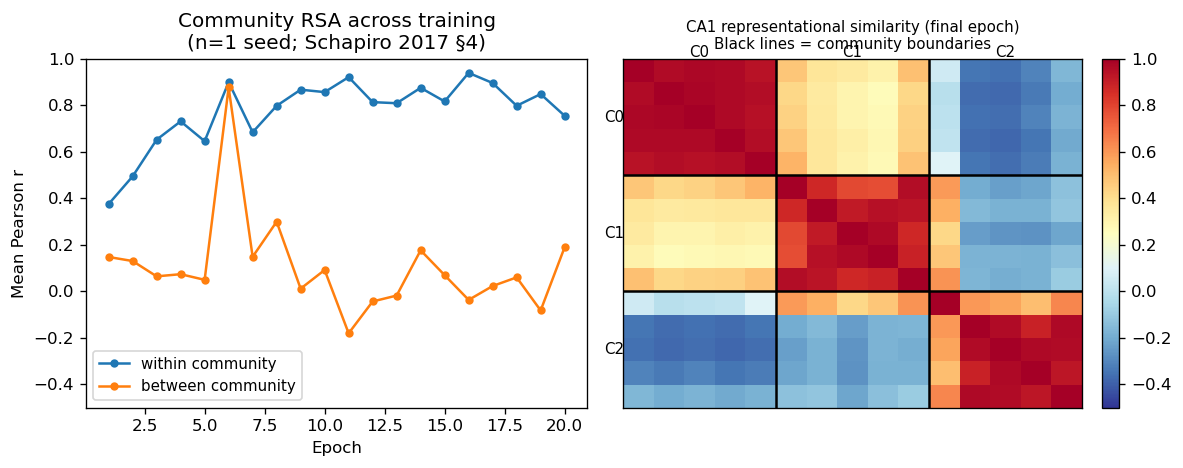

Final epoch — within: 0.756  |  between: 0.190


In [13]:
# GOAL: Visualize CA1 community structure — learning curve and RSA matrix
#
# Left: learning curve
#   within-community and between-community Pearson r scores across epochs.
#   A widening gap (within rising, between stable) indicates MSP is learning
#   the community structure.  Convergence before epoch 10 is ideal; a still-
#   rising curve means more epochs may be needed for a single seed.
#
# Right: RSA matrix (final epoch)
#   15×15 pairwise Pearson r between mean CA1 vectors, one per item.
#   Items are ordered by community (0–4: C0, 5–9: C1, 10–14: C2).
#   Community structure appears as three warm blocks on the diagonal.
#   Schapiro (2017) Fig. 3: this block structure is the core behavioral result.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: learning curve ---
ax = axes[0]
epochs = range(1, n_epochs + 1)
ax.plot(epochs, within,  label='within community',  color='C0', marker='o', markersize=4)
ax.plot(epochs, between, label='between community', color='C1', marker='o', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Pearson r')
ax.set_title('Community RSA across training\n(n=1 seed; Schapiro 2017 §4)')
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1)

# --- Right: RSA matrix ---
ax = axes[1]
im = ax.imshow(sim_mat, vmin=-0.5, vmax=1.0, cmap='RdYlBu_r', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for boundary in [5, 10]:
    ax.axhline(boundary - 0.5, color='black', linewidth=1.5)
    ax.axvline(boundary - 0.5, color='black', linewidth=1.5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('CA1 representational similarity (final epoch)\nBlack lines = community boundaries', fontsize=9)
for c, label in enumerate(['C0', 'C1', 'C2']):
    mid = c * 5 + 2
    ax.text(mid, -0.8, label, ha='center', va='center', fontsize=9)
    ax.text(-0.8, mid, label, ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(DIR_VIZ / 'M_Hip_RSA_10epochs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final epoch — within: {within[-1]:.3f}  |  between: {between[-1]:.3f}")

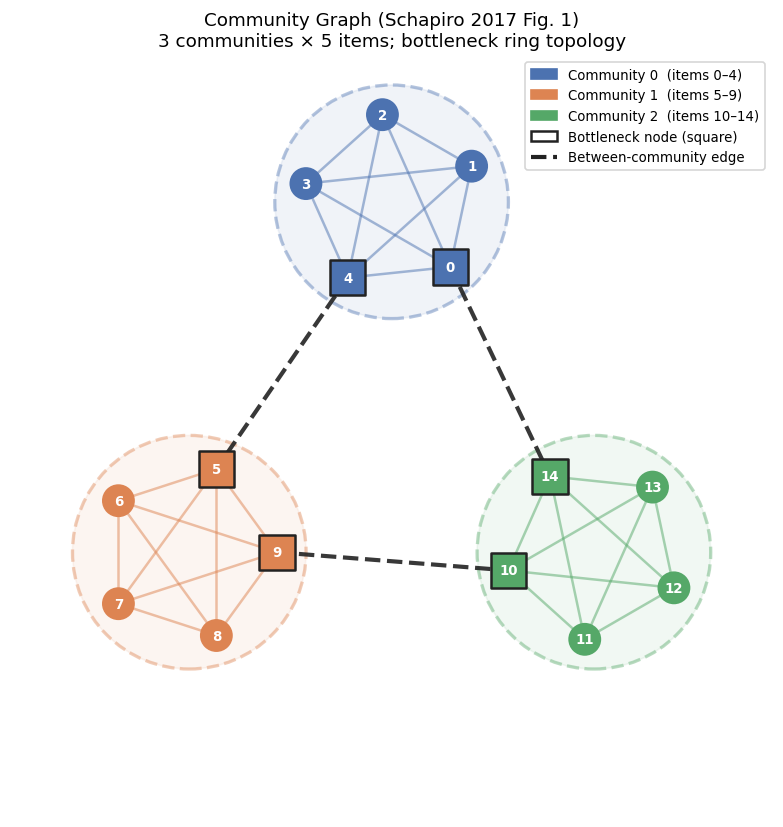

In [14]:
# GOAL: Visualize community graph structure (Schapiro 2017 Fig. 1)
#
# 3 communities × 5 items = 15 items total.
# Within each community: full clique (C(5,2) = 10 edges per community).
# Between communities: ring topology — last item of c connects to first item of (c+1)%3.
# 6 bottleneck nodes (2 per boundary); 3 between-community edges total.

N_COMMUNITIES = 3
IPC = 5

env = T_CommunityGraphEnv(n_communities=N_COMMUNITIES, items_per_community=IPC)
A = (env._transition_matrix > 0).astype(int)

fig, ax = plt.subplots(figsize=(7, 7))
plot_community_graph(ax, A, N_COMMUNITIES, IPC,
                     title='Community Graph (Schapiro 2017 Fig. 1)\n'
                           '3 communities × 5 items; bottleneck ring topology')
plt.tight_layout()
plt.savefig(DIR_VIZ / 'community_graph_structure.png', dpi=150, bbox_inches='tight')
plt.show()